In [1]:
# ============================================
# CELL 1: IMPORTS & DATA LOADING
# RUN THIS CELL FIRST
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# ============================================
# FIND AND LOAD DATA - AUTO-DETECTS PATH
# ============================================

# Try different possible paths
possible_paths = [
    'data/data.xlsx',                    # Current directory
    '../data/data.xlsx',                 # Parent directory
    r'C:\Users\MUSLIMAH\Desktop\credit-risk-model-1\data\data.xlsx',  # Full path
]

df = None
for path in possible_paths:
    if os.path.exists(path):
        print(f"✅ Found data at: {path}")
        df = pd.read_excel(path, engine='openpyxl')
        break

if df is None:
    print("❌ Could not find data.xlsx")
    print("\nSearching for Excel files...")
    for root, dirs, files in os.walk('.'):
        for file in files:
            if file.endswith('.xlsx'):
                print(f"   Found: {os.path.join(root, file)}")
    raise FileNotFoundError("Please check your data file location")

# ============================================
# DATA SUMMARY
# ============================================

print("\n" + "="*60)
print("CREDIT RISK / FRAUD DETECTION EDA")
print("="*60)
print(f"\n✅ Data loaded successfully!")
print(f"   Shape: {df.shape}")
print(f"   Rows: {df.shape[0]:,}")
print(f"   Columns: {df.shape[1]}")

# Identify column types
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\n📊 Column Breakdown:")
print(f"   Numerical columns ({len(num_cols)}): {num_cols}")
print(f"   Categorical columns ({len(cat_cols)}): {cat_cols[:5]}...")

# Check target variable
if 'FraudResult' in df.columns:
    fraud_rate = df['FraudResult'].mean()
    print(f"\n🎯 Target variable 'FraudResult':")
    print(f"   Fraud rate: {fraud_rate:.2%}")
    print(f"   Non-fraud: {(1-fraud_rate):.2%}")
elif 'default' in df.columns:
    default_rate = df['default'].mean()
    print(f"\n🎯 Target variable 'default':")
    print(f"   Default rate: {default_rate:.2%}")

print("\n" + "="*60)
print("READY TO RUN ANALYSIS CELLS")
print("="*60)

✅ Found data at: ../data/data.xlsx

CREDIT RISK / FRAUD DETECTION EDA

✅ Data loaded successfully!
   Shape: (95662, 16)
   Rows: 95,662
   Columns: 16

📊 Column Breakdown:
   Numerical columns (5): ['CountryCode', 'Amount', 'Value', 'PricingStrategy', 'FraudResult']
   Categorical columns (11): ['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId']...

🎯 Target variable 'FraudResult':
   Fraud rate: 0.20%
   Non-fraud: 99.80%

READY TO RUN ANALYSIS CELLS


In [2]:
# Data overview
print("="*50)
print("DATA OVERVIEW")
print("="*50)

print(f"\nDataset Shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

print("\nFirst 5 rows:")
df.head()

DATA OVERVIEW

Dataset Shape: (95662, 16)
Rows: 95,662
Columns: 16

First 5 rows:


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


In [3]:
# Data Types
print("="*50)
print("DATA TYPES")
print("="*50)

print(df.dtypes)

print(f"\nNumerical columns: {num_cols}")
print(f"Categorical columns: {cat_cols}")

DATA TYPES
TransactionId               str
BatchId                     str
AccountId                   str
SubscriptionId              str
CustomerId                  str
CurrencyCode                str
CountryCode               int64
ProviderId                  str
ProductId                   str
ProductCategory             str
ChannelId                   str
Amount                  float64
Value                     int64
TransactionStartTime        str
PricingStrategy           int64
FraudResult               int64
dtype: object

Numerical columns: ['CountryCode', 'Amount', 'Value', 'PricingStrategy', 'FraudResult']
Categorical columns: ['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId', 'CurrencyCode', 'ProviderId', 'ProductId', 'ProductCategory', 'ChannelId', 'TransactionStartTime']


In [4]:
# Summary statistics
print("="*50)
print("SUMMARY STATISTICS")
print("="*50)

df[num_cols].describe()

SUMMARY STATISTICS


,CountryCode,Amount,Value,PricingStrategy,FraudResult
count,95662.0,9.566200e+04,9.566200e+04,95662.000000,95662.000000
mean,256.0,6.717846e+03,9.900584e+03,2.255974,0.002018
std,0.0,1.233068e+05,1.231221e+05,0.732924,0.044872
min,256.0,-1.000000e+06,2.000000e+00,0.000000,0.000000
25%,256.0,-5.000000e+01,2.750000e+02,2.000000,0.000000
50%,256.0,1.000000e+03,1.000000e+03,2.000000,0.000000
75%,256.0,2.800000e+03,5.000000e+03,2.000000,0.000000
max,256.0,9.880000e+06,9.880000e+06,4.000000,1.000000


In [5]:
# Missing Values
print("="*50)
print("MISSING VALUES")
print("="*50)

missing = df.isnull().sum()
if missing.sum() == 0:
    print("✅ No missing values found!")
else:
    print(missing[missing > 0])

MISSING VALUES
✅ No missing values found!


NUMERICAL DISTRIBUTIONS


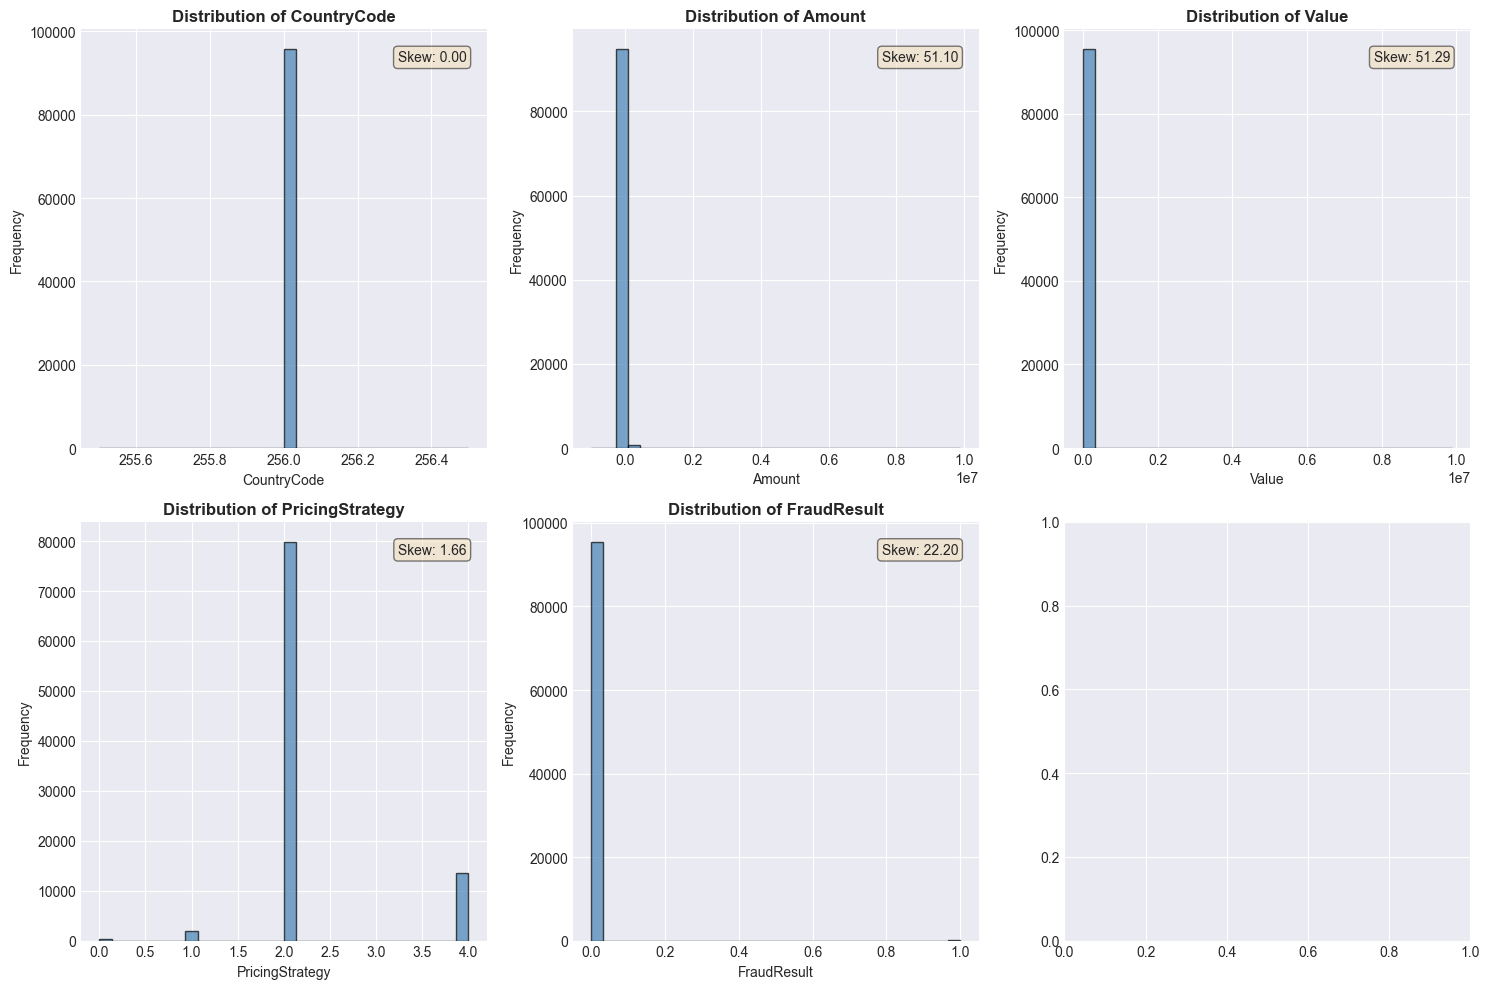

In [6]:
#  Numerical Distributions (Histograms)
print("="*50)
print("NUMERICAL DISTRIBUTIONS")
print("="*50)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(num_cols[:6]):
    axes[idx].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    
    # Add skewness
    skew_val = df[col].skew()
    axes[idx].text(0.95, 0.95, f'Skew: {skew_val:.2f}', 
                   transform=axes[idx].transAxes, ha='right', va='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

In [7]:
# Categorical Distributions
print("="*50)
print("CATEGORICAL DISTRIBUTIONS")
print("="*50)

for col in cat_cols[:4]:
    print(f"\n{col}:")
    print(df[col].value_counts().head())


CATEGORICAL DISTRIBUTIONS

TransactionId:
TransactionId
TransactionId_76871    1
TransactionId_73770    1
TransactionId_26203    1
TransactionId_380      1
TransactionId_28195    1
Name: count, dtype: int64

BatchId:
BatchId
BatchId_67019     28
BatchId_51870     16
BatchId_113893    14
BatchId_127204    12
BatchId_116835    10
Name: count, dtype: int64

AccountId:
AccountId
AccountId_4841    30893
AccountId_4249     4457
AccountId_4840     1738
AccountId_3206     1105
AccountId_318      1070
Name: count, dtype: int64

SubscriptionId:
SubscriptionId
SubscriptionId_3829    32630
SubscriptionId_4429     4457
SubscriptionId_1372     1105
SubscriptionId_3087     1070
SubscriptionId_4346      965
Name: count, dtype: int64


CORRELATION ANALYSIS


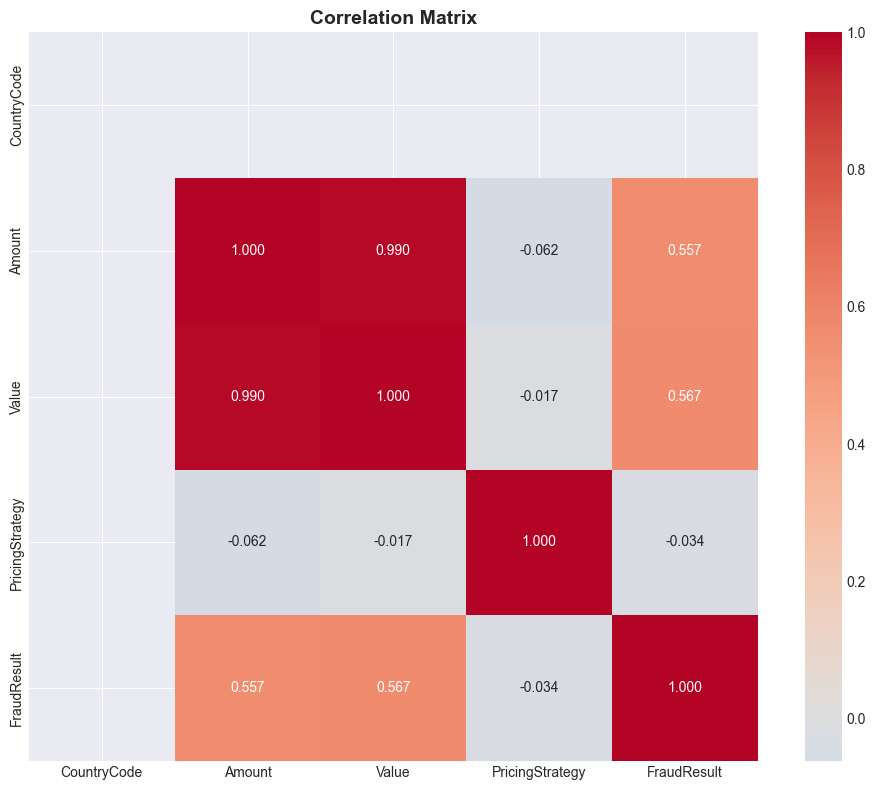


Correlations with FraudResult:
FraudResult        1.000000
Value              0.566739
Amount             0.557370
PricingStrategy   -0.033821
CountryCode             NaN
Name: FraudResult, dtype: float64


In [8]:
# Correlation Analysis
print("="*50)
print("CORRELATION ANALYSIS")
print("="*50)

plt.figure(figsize=(10, 8))
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f', square=True)
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlation with target
if 'FraudResult' in df.columns:
    print("\nCorrelations with FraudResult:")
    print(corr_matrix['FraudResult'].sort_values(ascending=False))

OUTLIER DETECTION


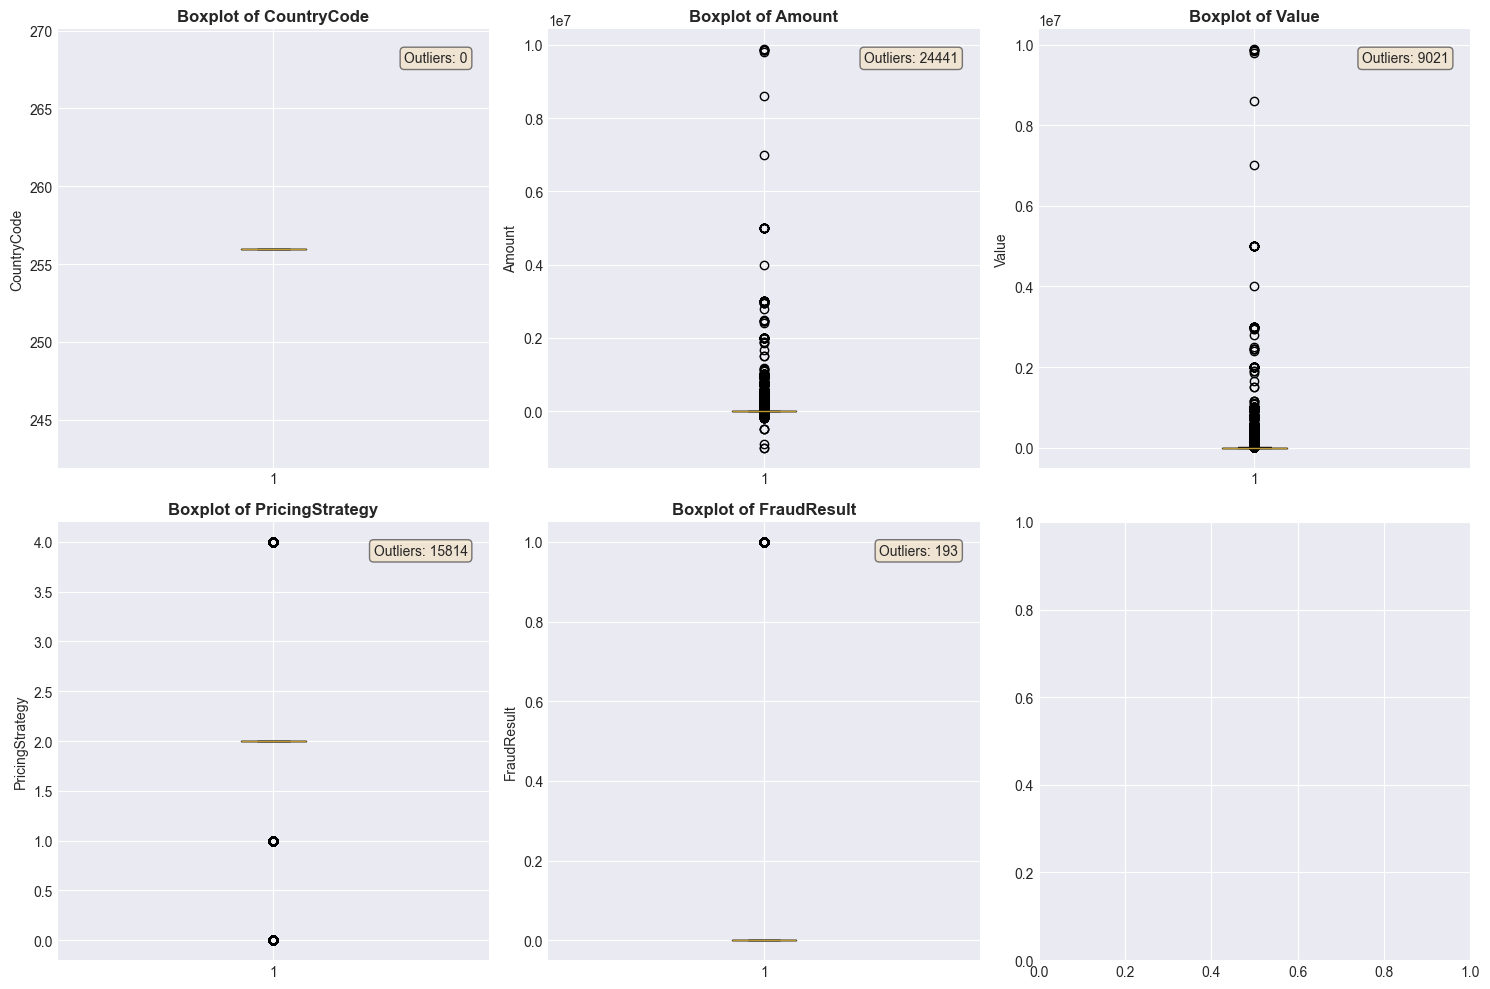

In [9]:
# Outlier Detection
print("="*50)
print("OUTLIER DETECTION")
print("="*50)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(num_cols[:6]):
    axes[idx].boxplot(df[col].dropna())
    axes[idx].set_title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel(col)
    
    # Count outliers
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outlier_count = len(df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)])
    axes[idx].text(0.95, 0.95, f'Outliers: {outlier_count}', 
                   transform=axes[idx].transAxes, ha='right', va='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

In [10]:
# Final Summary
print("="*60)
print("EDA SUMMARY - KEY FINDINGS")
print("="*60)

print(f"\n📊 DATASET OVERVIEW:")
print(f"   - Total rows: {len(df):,}")
print(f"   - Total columns: {len(df.columns)}")
print(f"   - Numerical: {len(num_cols)}")
print(f"   - Categorical: {len(cat_cols)}")

if 'FraudResult' in df.columns:
    print(f"   - Fraud rate: {df['FraudResult'].mean():.2%}")

print(f"\n📈 KEY INSIGHTS:")
for col in num_cols:
    skew_val = df[col].skew()
    if abs(skew_val) > 1:
        print(f"   - {col}: Highly skewed ({skew_val:.2f}) - needs transformation")

print(f"\n💡 RECOMMENDATIONS:")
print(f"   1. Check class imbalance in target variable")
print(f"   2. Apply log transformation to skewed features")
print(f"   3. Consider outlier treatment for features with many outliers")
print(f"   4. Use Weight of Evidence (WoE) for categorical encoding")

print("\n" + "="*60)
print("✅ TASK 2 - EDA COMPLETE!")
print("="*60)

EDA SUMMARY - KEY FINDINGS

📊 DATASET OVERVIEW:
   - Total rows: 95,662
   - Total columns: 16
   - Numerical: 5
   - Categorical: 11
   - Fraud rate: 0.20%

📈 KEY INSIGHTS:
   - Amount: Highly skewed (51.10) - needs transformation
   - Value: Highly skewed (51.29) - needs transformation
   - PricingStrategy: Highly skewed (1.66) - needs transformation
   - FraudResult: Highly skewed (22.20) - needs transformation

💡 RECOMMENDATIONS:
   1. Check class imbalance in target variable
   2. Apply log transformation to skewed features
   3. Consider outlier treatment for features with many outliers
   4. Use Weight of Evidence (WoE) for categorical encoding

✅ TASK 2 - EDA COMPLETE!
